In [7]:
! pip install -U langchain langchain-core langchain-community \
    langchain-text-splitters langchain-chroma \
    langchain-huggingface langchain-groq chromadb sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.9/136.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.3/558.3 kB 35.5 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.4.8
    Uninstalling langchain-core-1.4.8:
      Successfully uninstalled langchain-core-1.4.8
  Attempting uninstall: langchain
    Found existing installation: langchain 1.3.11
    Uninstalling langchain-1.3.11:
      Successfully uninstalled langchain-1.3.11


# Rag From Scratch: Overview

These notebooks walk through the process of building RAG app(s) from scratch.

They will build towards a broader understanding of the RAG langscape, as shown here:

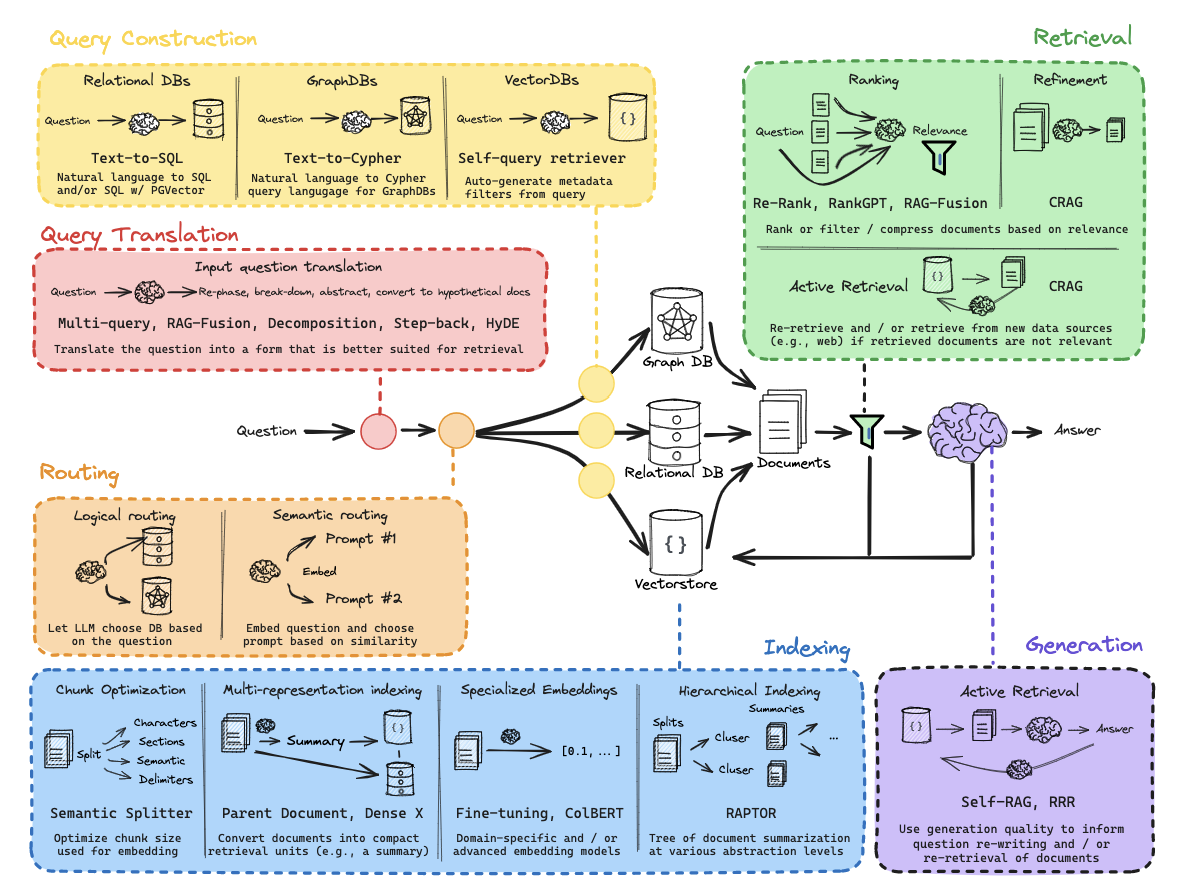

## Environment

`(1) Packages`

In [ ]:
import os
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGCHAIN_API_KEY'] = ""

In [ ]:
os.environ['GROQ_API_KEY'] = ""

## Part 1: Overview Indexing

[RAG quickstart](https://python.langchain.com/docs/use_cases/question_answering/quickstart)

In [5]:
import bs4

# from langchain import hub
from langchain_core.prompts import ChatPromptTemplate
from langchain_chroma import Chroma
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_community.document_loaders import WebBaseLoader

from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

# Load
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
docs = loader.load()

# Split
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
)
splits = text_splitter.split_documents(docs)

# Embeddings
embedding = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

# Vector Store
vectorstore = Chroma.from_documents(
    documents=splits,
    embedding=embedding,
)

# Retriever
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 4}
)

# Prompt
# prompt = hub.pull("rlm/rag-prompt")
prompt = ChatPromptTemplate.from_template("""
Use the following context to answer the question.

Context:
{context}

Question:
{question}

Answer:
""")

# LLM
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
)

# Helper
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# Chain
rag_chain = (
    {
        "context": retriever | format_docs,
        "question": RunnablePassthrough(),
    }
    | prompt
    | llm
    | StrOutputParser()
)

# Run
response = rag_chain.invoke("What is Task Decomposition?")
print(response)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Task decomposition is the process of breaking down a complex task into smaller, more manageable steps or subgoals. This can be done in various ways, including:

1. Using a Large Language Model (LLM) with simple prompting, such as "Steps for XYZ.\n1." or "What are the subgoals for achieving XYZ?"
2. Using task-specific instructions, such as "Write a story outline" for writing a novel.
3. Using human inputs to guide the decomposition process.
4. Utilizing techniques like Chain of Thought (CoT) and Tree of Thoughts, which involve instructing the model to "think step by step" and explore multiple reasoning possibilities at each step.
5. Outsourcing the planning step to an external classical planner, such as in the LLM+P approach, which uses the Planning Domain Definition Language (PDDL) as an intermediate interface to describe the planning problem.

The goal of task decomposition is to transform big tasks into multiple manageable tasks, making it easier for an agent to plan ahead and compl

In [8]:
len(splits)

63

## Part 2: Indexing

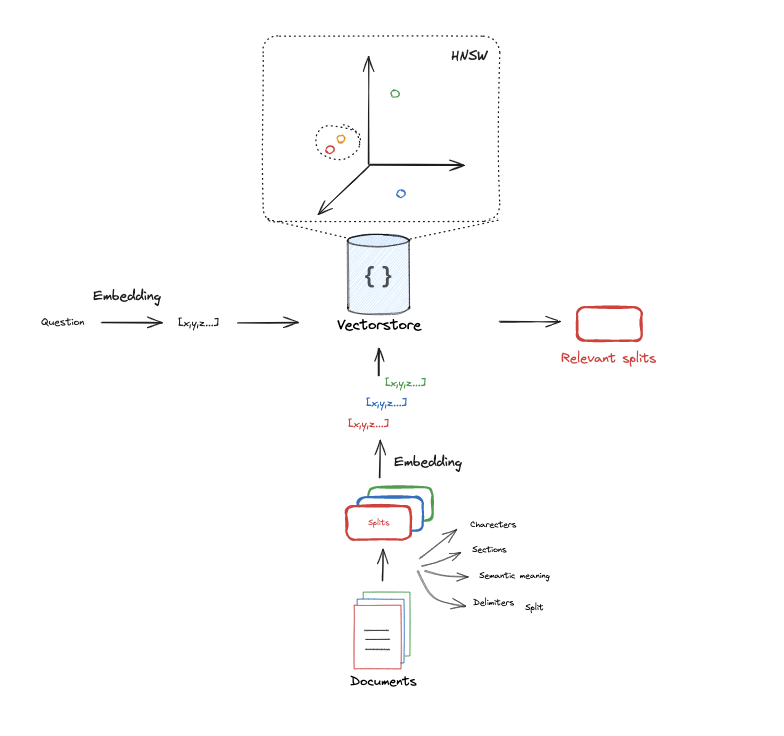

In [15]:
# Documents
question = "What is Task decomposition?"
document = """
Task decomposition is the process of breaking down a complex task into smaller, more manageable steps or subgoals. This can be done in various ways, including:

1. Using a Large Language Model (LLM) with simple prompting, such as "Steps for XYZ.\n1." or "What are the subgoals for achieving XYZ?"
2. Using task-specific instructions, such as "Write a story outline" for writing a novel.
3. Using human inputs to guide the decomposition process.
4. Utilizing techniques like Chain of Thought (CoT) and Tree of Thoughts, which involve instructing the model to "think step by step" and explore multiple reasoning possibilities at each step.
5. Outsourcing the planning step to an external classical planner, such as in the LLM+P approach, which uses the Planning Domain Definition Language (PDDL) as an intermediate interface to describe the planning problem.

The goal of task decomposition is to transform big tasks into multiple manageable tasks, making it easier for an agent to plan ahead and complete the task"
"""

In [11]:
import tiktoken

def num_tokens_from_string(string: str, encoding_name: str) -> int:
    """Returns the number of tokens in a text string."""
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens

num_tokens_from_string(question, "cl100k_base")

8

In [16]:
# from langchain_openai import OpenAIEmbeddings
# embd = OpenAIEmbeddings()
from langchain_huggingface import HuggingFaceEmbeddings
embd = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
query_result = embd.embed_query(question)
document_result = embd.embed_query(document)
print(len(query_result))
print(len(document_result))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

384
384


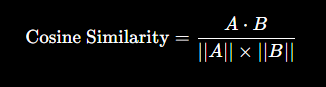

In [17]:
import numpy as np

def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    return dot_product / (norm_vec1 * norm_vec2)

similarity = cosine_similarity(query_result, document_result)
print("Cosine Similarity:", similarity)

Cosine Similarity: -0.06781762907357429


In [18]:
#### Document Load ####
# Load blog
import bs4
from langchain_community.document_loaders import WebBaseLoader
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
blog_docs = loader.load()

# 📌 LangChain Text Splitters Cheat Sheet

| Splitter | Best For | Advantages | Library |
|----------|----------|------------|----------|
| `CharacterTextSplitter` | Simple text | Fast & easy | `langchain_text_splitters` |
| `RecursiveCharacterTextSplitter` ⭐ | PDFs, Articles, General RAG | Preserves context by splitting Paragraph → Line → Sentence → Word | `langchain_text_splitters` |
| `RecursiveCharacterTextSplitter.from_tiktoken_encoder()` ⭐ | OpenAI / Token-based models | Splits by **tokens** instead of characters | `langchain_text_splitters` |
| `TokenTextSplitter` | Token-limited LLMs | Precise token control | `langchain_text_splitters` |
| `MarkdownHeaderTextSplitter` | Markdown Docs | Splits by `#`, `##`, `###` headers | `langchain_text_splitters` |
| `HTMLHeaderTextSplitter` | HTML / Web Pages | Splits by HTML headings (`<h1>`, `<h2>`) | `langchain_text_splitters` |
| `PythonCodeTextSplitter` | Source Code | Keeps functions & classes together | `langchain_text_splitters` |
| `RecursiveJsonSplitter` | JSON Files | Preserves JSON structure | `langchain_text_splitters` |
| `LatexTextSplitter` | Research Papers | Splits by LaTeX sections/equations | `langchain_text_splitters` |
| `SemanticChunker` ⭐ | High-quality RAG | Splits based on **semantic meaning** using embeddings | `langchain_experimental.text_splitter` |

## 🚀 Quick Guide

- **General RAG (PDF, DOCX, TXT)** → `RecursiveCharacterTextSplitter`
- **OpenAI Models** → `RecursiveCharacterTextSplitter.from_tiktoken_encoder()`
- **Markdown Docs** → `MarkdownHeaderTextSplitter`
- **Web Pages (HTML)** → `HTMLHeaderTextSplitter`
- **Code RAG** → `PythonCodeTextSplitter`
- **JSON Data** → `RecursiveJsonSplitter`
- **Best Retrieval Quality** → `SemanticChunker`

In [21]:
# Split
from langchain_text_splitters import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=300,
    chunk_overlap=50)

# Make splits
splits = text_splitter.split_documents(blog_docs)
print(len(splits))

50


## Part 3: Retrieval

In [23]:
# Vector Store
## OpenAIEmbeddings
# from langchain_openai import OpenAIEmbeddings
# from langchain_community.vectorstores import Chroma
# vectorstore = Chroma.from_documents(documents=splits,
#                                     embedding=OpenAIEmbeddings())
# retriever = vectorstore.as_retriever()

## HuggingFaceEmbeddings
from langchain_huggingface import HuggingFaceEmbeddings
embd = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
from langchain_community.vectorstores import Chroma
vectorstore = Chroma.from_documents(documents=splits,
                                    embedding=embd)

retriever = vectorstore.as_retriever(search_kwargs={"k": 4}) # return 4 chunks


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [30]:
# The retriever returns a list of Document objects, so we need to format them
# using the helper function defined earlier (format_docs).
docs = retriever.invoke("What is Task Decomposition?")
print(format_docs(docs))
print("="*20)
print(len(docs))

Component One: Planning#
A complicated task usually involves many steps. An agent needs to know what they are and plan ahead.
Task Decomposition#
Chain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” to utilize more test-time computation to decompose hard tasks into smaller and simpler steps. CoT transforms big tasks into multiple manageable tasks and shed lights into an interpretation of the model’s thinking process.
Tree of Thoughts (Yao et al. 2023) extends CoT by exploring multiple reasoning possibilities at each step. It first decomposes the problem into multiple thought steps and generates multiple thoughts per step, creating a tree structure. The search process can be BFS (breadth-first search) or DFS (depth-first search) with each state evaluated by a classifier (via a prompt) or majority vote.
Task decomposition can be done (1) by LLM with simple prompt

## Part 4: Generation

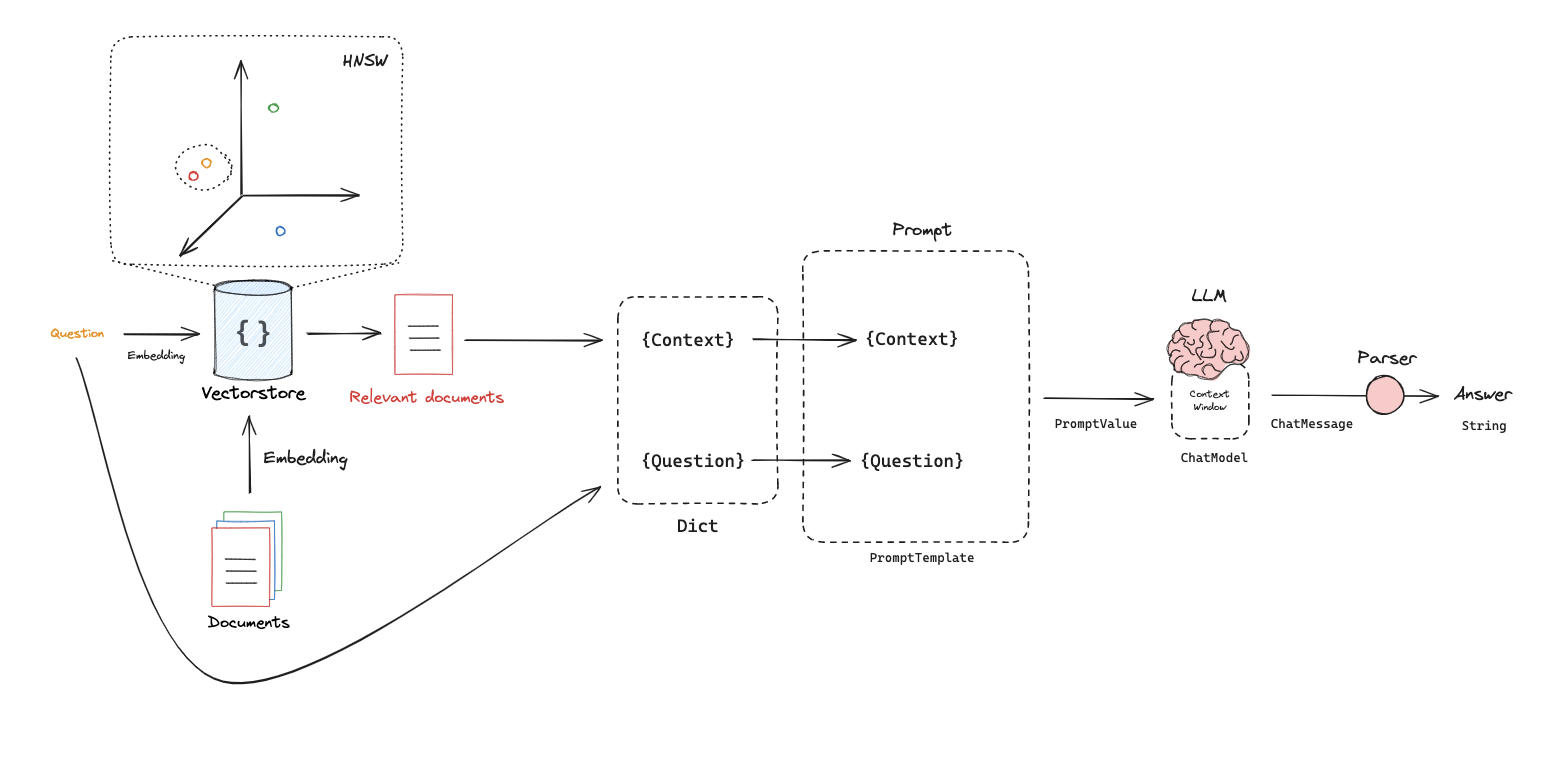

In [32]:
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate

# Prompt
template = """Answer the question based only on the following context:
{context}

Question: {question}
"""

prompt = ChatPromptTemplate.from_template(template)
prompt

ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='Answer the question based only on the following context:\n{context}\n\nQuestion: {question}\n'), additional_kwargs={})])

In [33]:
# LLM
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
)

In [34]:
# Chain
chain = prompt | llm

In [35]:
# Run
chain.invoke({"context":docs,"question":"What is Task Decomposition?"})

AIMessage(content='Task decomposition is the process of breaking down a complicated task into smaller, more manageable steps. This can be done in several ways, including:\n\n1. Using a large language model (LLM) with simple prompting, such as asking for "Steps for XYZ" or "What are the subgoals for achieving XYZ?"\n2. Using task-specific instructions, such as "Write a story outline" for writing a novel\n3. With human inputs\n\nAdditionally, techniques like Chain of Thought (CoT) and Tree of Thoughts can be used to decompose tasks into smaller steps, and approaches like LLM+P can outsource the planning step to an external classical planner using the Planning Domain Definition Language (PDDL).', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 144, 'prompt_tokens': 1135, 'total_tokens': 1279, 'completion_time': 0.353559991, 'completion_tokens_details': None, 'prompt_time': 0.157924566, 'prompt_tokens_details': None, 'queue_time': 0.256000159, 'total_time': 0.

In [36]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

rag_chain = (
    {"context": retriever, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

rag_chain.invoke("What is Task Decomposition?")

'Task decomposition is the process of breaking down a complicated task into smaller, more manageable steps. It can be done in several ways, including:\n\n1. Using a Large Language Model (LLM) with simple prompting, such as asking for "Steps for XYZ" or "What are the subgoals for achieving XYZ?"\n2. Using task-specific instructions, such as "Write a story outline" for writing a novel\n3. With human inputs\n\nAdditionally, techniques like Chain of Thought (CoT) and Tree of Thoughts can be used to decompose tasks into smaller steps and explore multiple reasoning possibilities. Another approach, LLM+P, involves using an external classical planner to do long-horizon planning, where the LLM translates the problem into a Planning Domain Definition Language (PDDL) and then requests a plan from the planner.'